In [3]:
import pandas as pd

df = pd.read_csv("Starbucks_reviews.csv", encoding="utf-8")
df.head()

df.columns

Index(['name', 'location', 'Date', 'Rating', 'Review', 'Image_Links'], dtype='object')

## 1. Word Cloud of All Starbucks Reviews
This word cloud shows the most common words customers use when describing their Starbucks experiences.

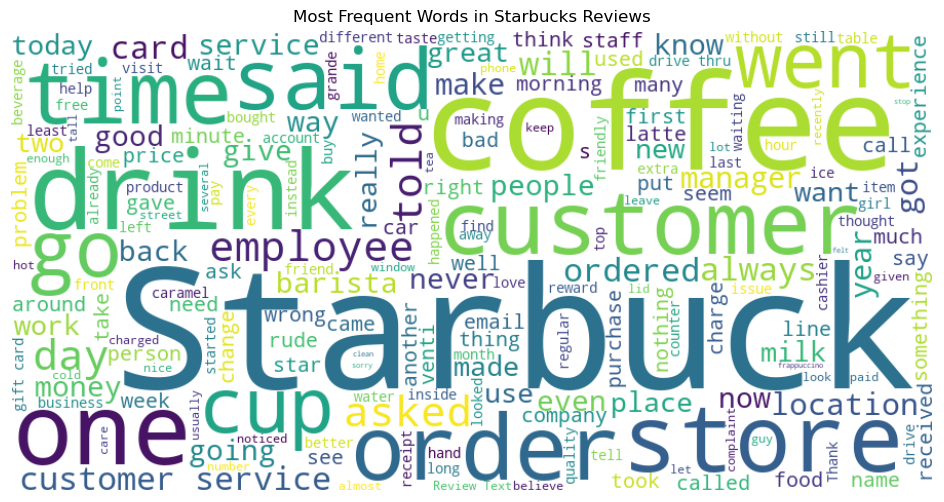

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(df['Review'].astype(str))

wc = WordCloud(width=900, height=450, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in Starbucks Reviews")
plt.show()

Large words like coffee, service, friendly, or order typically dominate, revealing what customers focus on most in their feedback.

## 2. Sentiment Distribution Across All Reviews
This histogram shows how positive or negative the reviews are overall.

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Haley\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


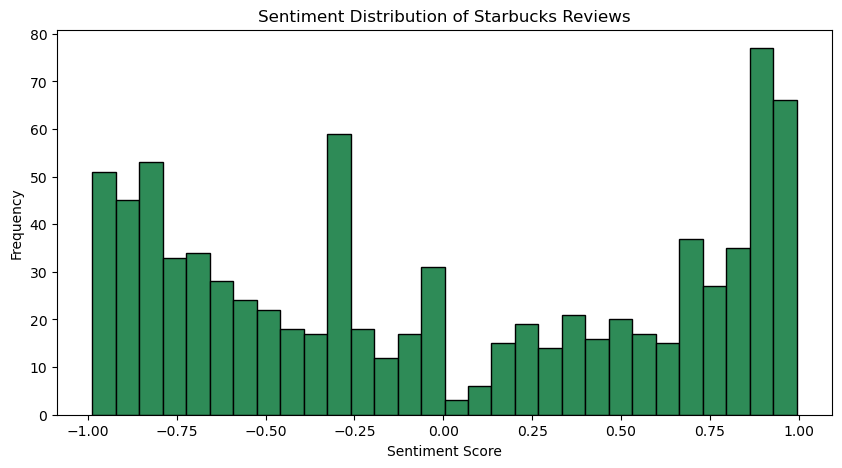

In [6]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

df['sentiment'] = df['Review'].astype(str).apply(lambda x: sia.polarity_scores(x)['compound'])

plt.figure(figsize=(10,5))
plt.hist(df['sentiment'], bins=30, color="seagreen", edgecolor="black")
plt.title("Sentiment Distribution of Starbucks Reviews")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

If the distribution leans right (positive), customers generally express satisfaction. A left-leaning distribution indicates more complains or negative experiences.

## 3. Most Common Words Bar Chart (Cleaned Text)
This bar chart shows the top 15 most frequent meaningful words in the review text.

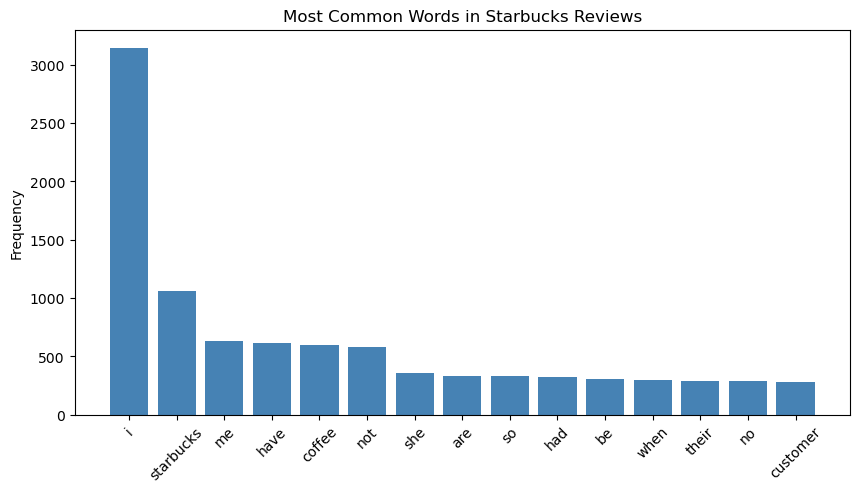

In [7]:
import re
from collections import Counter
import matplotlib.pyplot as plt

# Simple text cleaning
text = " ".join(df['Review'].astype(str)).lower()
text = re.sub(r'[^a-z\s]', '', text)

words = text.split()
stopwords = set(["the","and","to","a","of","for","is","it","in","was","my","they","with","on","at","this","that","but","we","you"])
filtered = [w for w in words if w not in stopwords]

counts = Counter(filtered).most_common(15)

words_list, freq_list = zip(*counts)

plt.figure(figsize=(10,5))
plt.bar(words_list, freq_list, color="steelblue")
plt.xticks(rotation=45)
plt.title("Most Common Words in Starbucks Reviews")
plt.ylabel("Frequency")
plt.show()

Unlike a word cloud, this chart gives a precise count of how often each word appears, making it easier to compare which themes dominate customer feedback.